In [1]:
import torch
from torch.nn import functional as F
from torchvision import transforms as T
from torchvision.models import vgg19
from torch_snippets import *

In [2]:
preprocess = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.458,0.456,0.406], std=[0.229, 0.224, 0.225]),
    T.Lambda(lambda x: x.mul_(255))
])# normaliza o tensor
postprocess = T.Compose([
    T.Lambda(lambda x: x.mul_(1./255)),
    T.Normalize(mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],std=[1/0.229, 1/0.224, 1/0.225]),
])# remove a normalização para ver sem a normalização

In [3]:
class GramMatrix(nn.Module):
    def forward(self, input):
        b,c,h,w = input.size()# pega as diferentes dimensoes do feature map, batch, canal, altura e largura
        feat = input.view(b, c, h*w)# transforma em vetores( como um Flatten)
        G = feat@feat.transpose(1,2)# mede a correlação das caracteristicas capturandoo textura, bordas e cores
        G.div_(h*w)
        return G

class GramMSELoss(nn.Module):#mede a diferença de estilo das duas imagens
    def forward(self, input, target):
        out = F.mse_loss(GramMatrix()(input), target)
        return(out)

class vgg19_modified(nn.Module):
    def __init__(self):
        super().__init__()
        features = list(vgg19(pretrained = True).features)# pega um rede pré treinada, pegando somente a parte convolucional da rede
        self.features = nn.ModuleList(features).eval()
    def forward(self, x, layers=[]):
        order = np.argsort(layers)
        _results, results = [], []
        for ix,model in enumerate(self.features):
            x = model(x)
            if ix in layers: _results.append(x)
        for o in order: results.append(_results[o])
        return results if layers is not [] else x

In [4]:
vgg = vgg19_modified().to(device)

/home/beuren/anaconda3/lib/python3.12/site-packages/torchvision/models/_utils.py:207: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/beuren/anaconda3/lib/python3.12/site-packages/torchvision/models/_utils.py:222: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [5]:
!wget https://easydrawingguides.com/wp-content/uploads/2016/10/how-to-draw-an-elephant-featured-image-1200-1024x822.png
!wget https://www.neh.gov/sites/default/files/2022-09/Fall_2022_web-images_Picasso_32.jpg

--2026-08-31 16:10:38--  https://easydrawingguides.com/wp-content/uploads/2016/10/how-to-draw-an-elephant-featured-image-1200-1024x822.png
Resolvendo easydrawingguides.com (easydrawingguides.com)... 104.19.154.92
Conectando-se a easydrawingguides.com (easydrawingguides.com)|104.19.154.92|:443... conectado.
A requisição HTTP foi enviada, aguardando resposta... 200 OK
Tamanho: 188359 (184K) [image/png]
Salvando em: ‘how-to-draw-an-elephant-featured-image-1200-1024x822.png.1’

how-to-draw-an-elep 100%[===================>] 183,94K  --.-KB/s    em 0,1s    

2026-08-31 16:10:38 (1,61 MB/s) - ‘how-to-draw-an-elephant-featured-image-1200-1024x822.png.1’ salvo [188359/188359]

--2026-08-31 16:10:38--  https://www.neh.gov/sites/default/files/2022-09/Fall_2022_web-images_Picasso_32.jpg
Resolvendo www.neh.gov (www.neh.gov)... 23.21.228.79
Conectando-se a www.neh.gov (www.neh.gov)|23.21.228.79|:443... conectado.
A requisição HTTP foi enviada, aguardando resposta... 200 OK
Tamanho: 5309491 (5,1M) [

In [6]:
imgs = [Image.open(path).resize((512,512)).convert('RGB') for path in ['Fall_2022_web-images_Picasso_32.jpg', 'how-to-draw-an-elephant-featured-image-1200-1024x822.png']]
style_image, content_image = [preprocess(img).to(device)[None] for img in imgs]
# abre e redimensiona as duas imagens, depois aplica o preprocess e adiciona a dimensao de batch

In [7]:
opt_img = content_image.data.clone()
opt_img.requires_grad = True
# cria a imagem que sera otimizada, comecando como copia do conteudo

In [8]:
style_layers = [0, 5, 10, 19, 28]
content_layers = [21]
loss_layers = style_layers + content_layers
# define quais camadas da vgg serao usadas para medir estilo e conteudo

In [9]:
loss_fns = [GramMSELoss()] * len(style_layers) + [nn.MSELoss()] * len(content_layers)
loss_fns = [loss_fn.to(device) for loss_fn in loss_fns]
# uma loss para cada camada de estilo, e MSE comum para a camada de conteudo

In [10]:
style_weights = [1000/n**2 for n in [64,128,256,512,512]]
content_weights = [1]
weights = style_weights + content_weights
# pesos para balancear a contribuicao de cada camada na loss total

In [11]:
style_targets = [GramMatrix()(A).detach() for A in vgg(style_image, style_layers)]
content_targets = [A.detach() for A in vgg(content_image, content_layers)]
targets = style_targets + content_targets
# calcula a gram matrix de estilo e as ativacoes de conteudo das imagens 

In [12]:
max_iters = 500
optimizer = optim.LBFGS([opt_img])
log = Report(max_iters)

In [13]:
iters = 0
while iters < max_iters:# a cada iter calcula o loss total e ajusta os pixels da imagem otimizada
    def closure():
        global iters
        iters += 1
        optimizer.zero_grad()
        out = vgg(opt_img, loss_layers)
        layer_losses = [weights[a] * loss_fns[a](A, targets[a]) for a,A in enumerate(out)]
        loss = sum(layer_losses)
        loss.backward()
        log.record(pos=iters, loss=loss, end='\r')
        return loss
    optimizer.step(closure)

EPOCH: 500.000  loss: 1194404.375  (1218.25s - 0.00s remaining)))))

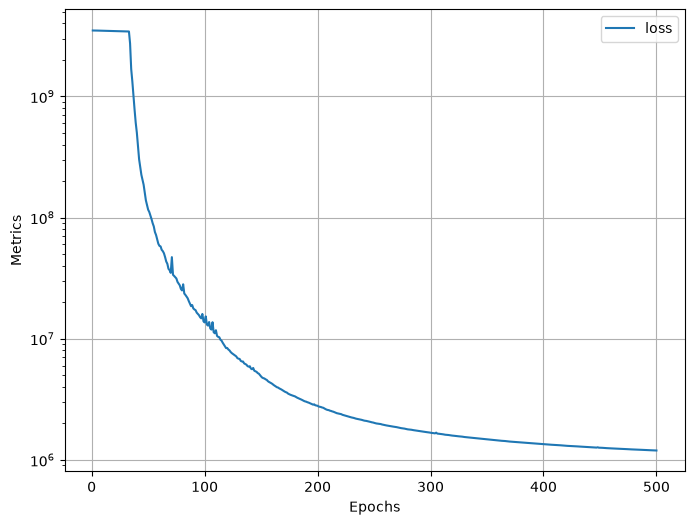

In [14]:
log.plot(log=True)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8918345..1.6889154].


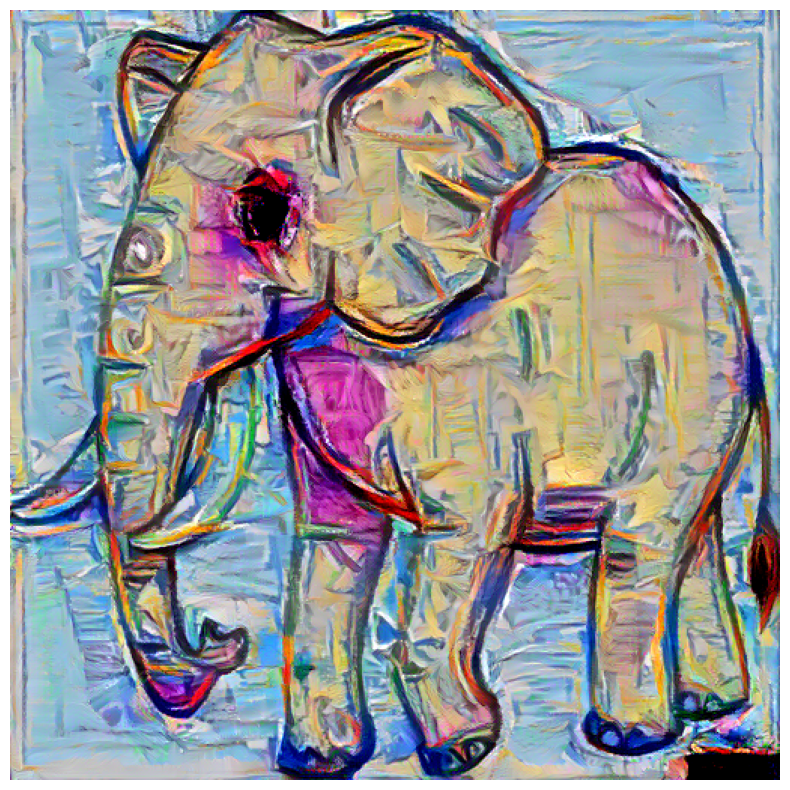

In [15]:
with torch.no_grad():
    out_img = postprocess(opt_img[0]).permute(1,2,0)
show(out_img)

In [ ]:
print()